# Recommendation EDA

This notebook loads the recommendation dataset, checks user behavior patterns, and highlights the product and event characteristics that matter for personalization.


{'users': 50, 'items': 30, 'events': 900, 'transactions': 99, 'event_types': ['addtocart', 'transaction', 'view'], 'missing_values': 0, 'duplicates': 2, 'start_time': Timestamp('2024-01-01 00:00:00'), 'end_time': Timestamp('2024-01-16 04:00:00')}

Top products by event count:
item_id
10    44
16    43
23    41
8     39
26    35
14    35
20    34
11    34
24    33
3     32
Name: count, dtype: int64

Top users by activity:
user_id
5     28
50    25
27    24
26    24
6     24
37    24
40    23
47    23
17    23
22    22
Name: count, dtype: int64


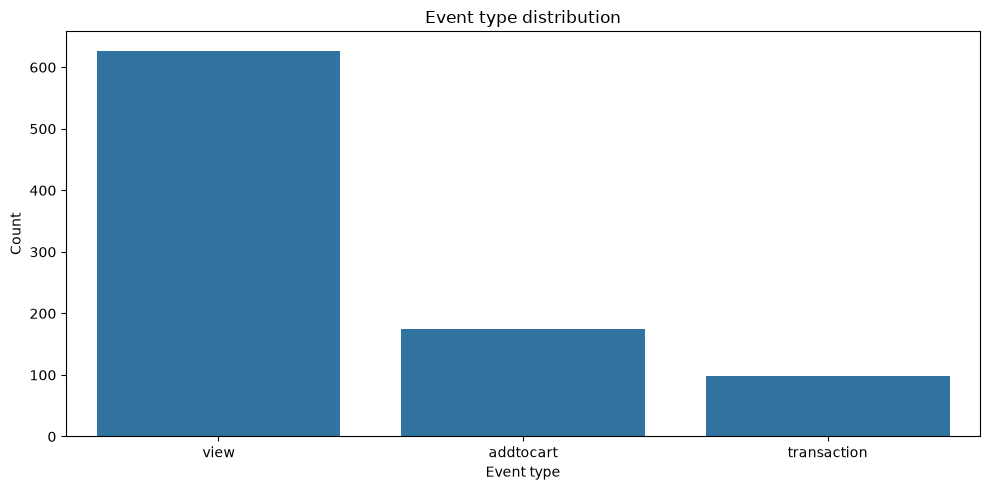

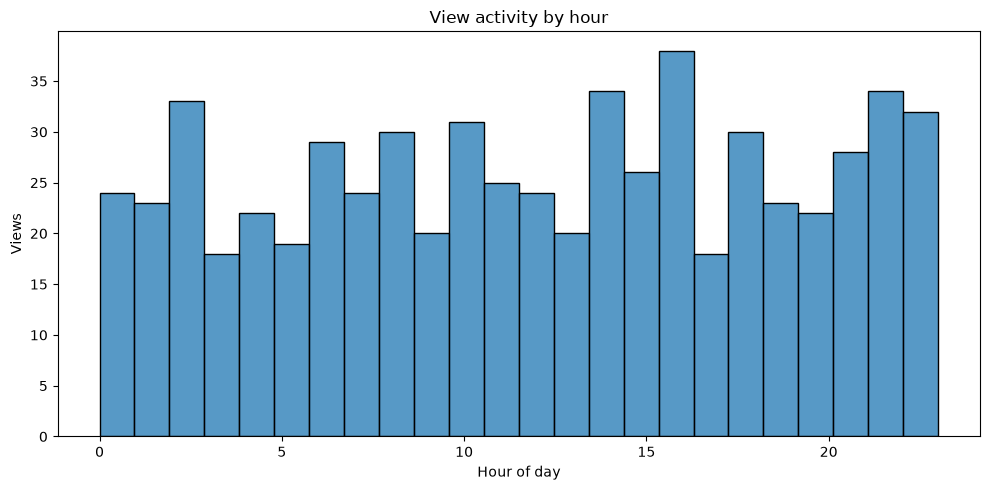


Interaction table shape: (673, 4)
   user_id  item_id  interaction_score last_interaction_at
0        1       10                  6 2024-01-12 05:00:00
1        1       15                  5 2024-01-05 10:00:00
2        1       24                  5 2024-01-09 19:00:00
3        1        3                  4 2024-01-13 18:00:00
4        1        2                  3 2024-01-07 23:00:00


In [4]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
for candidate in [project_root, *project_root.parents]:
    if (candidate / 'src').exists() and (candidate / 'scripts').exists():
        project_root = candidate
        break
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.generate_demo_data import ensure_demo_data
from src.recommendation.preprocessing import build_user_item_interactions

ensure_demo_data()

raw_dir = project_root / 'data' / 'raw' / 'recommendation'
events = pd.read_csv(raw_dir / 'events.csv')
events['timestamp'] = pd.to_numeric(events['timestamp'], errors='coerce')
events['event_time'] = pd.to_datetime(events['timestamp'], unit='ms', errors='coerce')

summary = {
    'users': events['user_id'].nunique(),
    'items': events['item_id'].nunique(),
    'events': len(events),
    'transactions': int((events['event_type'] == 'transaction').sum()),
    'event_types': sorted(events['event_type'].dropna().unique().tolist()),
    'missing_values': int(events.isna().sum().sum()),
    'duplicates': int(events.duplicated().sum()),
    'start_time': events['event_time'].min(),
    'end_time': events['event_time'].max(),
}

print(summary)

print('\nTop products by event count:')
print(events['item_id'].value_counts().head(10))

print('\nTop users by activity:')
print(events['user_id'].value_counts().head(10))

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=events, x='event_type', order=events['event_type'].value_counts().index)
ax.set_title('Event type distribution')
ax.set_xlabel('Event type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

views = events[events['event_type'] == 'view'].copy()
if not views.empty:
    views['hour'] = views['event_time'].dt.hour
    plt.figure(figsize=(10, 5))
    sns.histplot(views['hour'], bins=24, kde=False)
    plt.title('View activity by hour')
    plt.xlabel('Hour of day')
    plt.ylabel('Views')
    plt.tight_layout()
    plt.show()

interactions = build_user_item_interactions()
print('\nInteraction table shape:', interactions.shape)
print(interactions.head())
